## 1. Setup: extract German data

English data now comes directly from the TED Talks Excel file (no zip needed). Only German still needs to be extracted from a zip archive.

In [3]:
import zipfile
import os

# ZIP file name for German data
de_zip = "German_translations.zip"   # change this to your actual filename

# Output folder
de_folder = "/content/German_translations"
os.makedirs(de_folder, exist_ok=True)

# Extract German
with zipfile.ZipFile(de_zip, "r") as zip_ref:
    zip_ref.extractall(de_folder)

print("German files extracted to:", de_folder)

German files extracted to: /content/German_translations


## 2. Standardize domain names

The German files use short codes (e.g. `Bus`, `Edu`, `Sci`) while the English file already uses full names (e.g. `Business`, `Education`, `Natural Science`). This mapping makes sure both datasets use the **same full domain names**, so tables and plots are directly comparable.

In [16]:
DOMAIN_FULL_NAMES = {
    "Art": "Art",
    "Bus": "Business",
    "Business": "Business",
    "Edu": "Education",
    "Education": "Education",
    "Ent": "Entertainment",
    "Entertainment": "Entertainment",
    "His": "History",
    "History": "History",
    "Med": "Medicine",
    "Medicine": "Medicine",
    "Phi": "Philosophy",
    "Philosophy": "Philosophy",
    "Pol": "Politics",
    "Politics & Law": "Politics",
    "Psy": "Psychology",
    "Psychology": "Psychology",
    "Sci": "Science",
    "Natural Science": "Science",
    "Tech": "Technology",
    "Technology": "Technology",
}

def standardize_domain(series):
    """Map short domain codes (or already-full names) to a single consistent full name."""
    mapped = series.map(DOMAIN_FULL_NAMES)
    return mapped.fillna(series)

## 3. Load German texts (from extracted zip)

In [17]:
import pandas as pd
import glob
import os

def load_texts_from_folder(folder_path):
    """
    Read all .xlsx files in a folder and return one row per unique text.

    A text is identified by the 'file' column.
    Each text gets one Domain and Gender.
    """

    records = {}
    conflicts = []

    # Find all Excel files, including files in subfolders
    xlsx_files = glob.glob(
        os.path.join(folder_path, "**", "*.xlsx"),
        recursive=True
    )

    print(f"Found {len(xlsx_files)} Excel files in {folder_path}")

    if not xlsx_files:
        raise ValueError(f"No .xlsx files found in {folder_path}")

    for xlsx_path in xlsx_files:

        df = pd.read_excel(
            xlsx_path,
            usecols=["file", "Domain", "Gender"]
        )

        df = df.dropna(subset=["file"])

        for file_name, domain, gender in df[
            ["file", "Domain", "Gender"]
        ].itertuples(index=False):

            if file_name in records:

                if records[file_name] != (domain, gender):
                    conflicts.append(
                        (
                            file_name,
                            records[file_name],
                            (domain, gender),
                            xlsx_path
                        )
                    )

            else:
                records[file_name] = (domain, gender)

    if conflicts:
        print(
            f"\nWARNING: {len(conflicts)} texts had "
            "inconsistent Domain/Gender information."
        )

        print("First 5 conflicts:")
        for c in conflicts[:5]:
            print(c)

    out = pd.DataFrame(
        [
            (file_name, domain, gender)
            for file_name, (domain, gender) in records.items()
        ],
        columns=["file", "Domain", "Gender"]
    )

    return out

In [18]:
de_texts = load_texts_from_folder(de_folder)
de_texts["Domain"] = standardize_domain(de_texts["Domain"])

print("German unique texts:", len(de_texts))

Found 7 Excel files in /content/German_translations
German unique texts: 156


## 4. Load English texts (directly from the TED Talks Excel file)

No zip file is used for English anymore — texts are read straight from `TED Data-All Talks (2).xlsx`.

In [19]:
en_file = "English.xlsx"

en_df = pd.read_excel(
    en_file,
    sheet_name="Full_table"
)

en_texts = (
    en_df[["ID", "Topic", "Gender"]]
    .dropna(subset=["ID"])
    .drop_duplicates(subset=["ID"])
    .rename(columns={"ID": "file", "Topic": "Domain"})
    .copy()
)

en_texts["Domain"] = standardize_domain(en_texts["Domain"])

print("English unique texts:", len(en_texts))

English unique texts: 190


## 5. Frequency and percentage tables

In [20]:
def domain_gender_frequency_table(texts_df):

    table = pd.crosstab(
        texts_df["Domain"],
        texts_df["Gender"]
    )

    table["Total"] = table.sum(axis=1)

    # Add total row
    table.loc["Total"] = table.sum(axis=0)

    return table


def domain_gender_percentage_table(texts_df):

    # Count gender within each domain
    counts = pd.crosstab(
        texts_df["Domain"],
        texts_df["Gender"]
    )

    # Convert each domain to percentages
    percentages = counts.div(
        counts.sum(axis=1),
        axis=0
    ) * 100

    return percentages.round(2)

In [21]:
# English
en_frequency = domain_gender_frequency_table(en_texts)
en_percentage = domain_gender_percentage_table(en_texts)

# German
de_frequency = domain_gender_frequency_table(de_texts)
de_percentage = domain_gender_percentage_table(de_texts)

In [22]:
print("========== ENGLISH: RAW FREQUENCIES ==========")
display(en_frequency)


print("\n========== GERMAN: RAW FREQUENCIES ==========")
display(de_frequency)


========== ENGLISH: RAW FREQUENCIES ==========


Gender,F,M,Total
Domain,,,
Art,6,10,16
Business,6,10,16
Education,9,6,15
Entertainment,7,8,15
History,8,7,15
Medicine,7,10,17
Philosophy,2,13,15
Politics,11,6,17
Psychology,12,5,17



========== GERMAN: RAW FREQUENCIES ==========


Gender,F,M,Total
Domain,,,
Art,4,10,14
Business,5,9,14
Education,9,6,15
Entertainment,5,4,9
History,6,5,11
Medicine,4,7,11
Philosophy,2,13,15
Politics,9,6,15
Psychology,10,5,15


## 6. Plots: gender distribution across domains

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_gender_stacked(df, title):

    # Count unique texts per Domain x Gender
    counts = pd.crosstab(
        df["Domain"],
        df["Gender"]
    )

    # Create figure
    fig, ax = plt.subplots(figsize=(13, 7))

    # Stacked bar chart
    counts.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    # Add individual counts inside each segment
    for bar_index, domain in enumerate(counts.index):

        cumulative = 0

        for gender in counts.columns:

            value = counts.loc[domain, gender]

            if value > 0:

                # Put count in middle of segment
                ax.text(
                    bar_index,
                    cumulative + value / 2,
                    str(value),
                    ha="center",
                    va="center",
                    color="white",
                    fontweight="bold",
                    fontsize=11
                )

                cumulative += value

        # Total above the bar
        total = counts.loc[domain].sum()

        ax.text(
            bar_index,
            total + 0.5,
            f"{total}",
            ha="center",
            va="bottom",
            fontweight="bold",
            color="gray",
            fontsize=11
        )

    # Labels
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("Domain", fontsize=12)
    ax.set_ylabel("Number of texts", fontsize=12)

    # Rotate domain names
    plt.xticks(
        rotation=45,
        ha="right"
    )

    # Legend
    ax.legend(
        title="Gender",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    # Give some space above totals
    ax.set_ylim(
        0,
        counts.sum(axis=1).max() * 1.15
    )

    plt.tight_layout()
    plt.show()

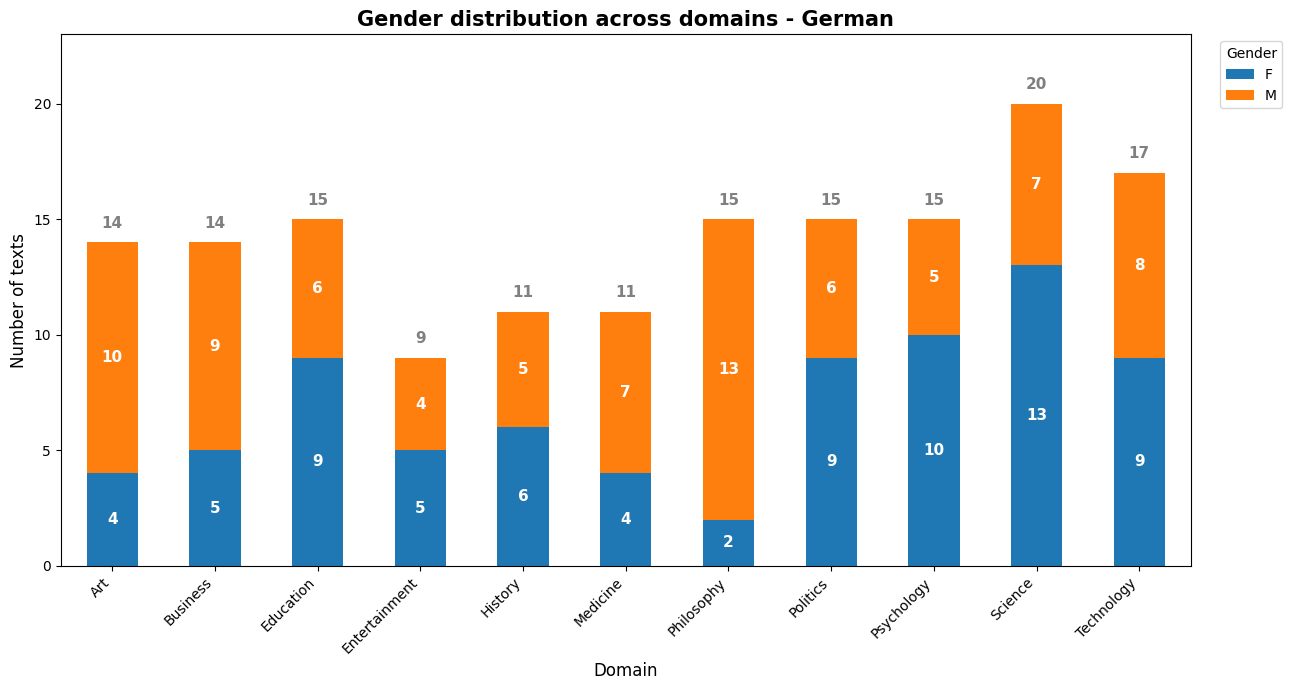

In [24]:
# German
plot_gender_stacked(
    de_texts,
    "Gender distribution across domains - German"
)

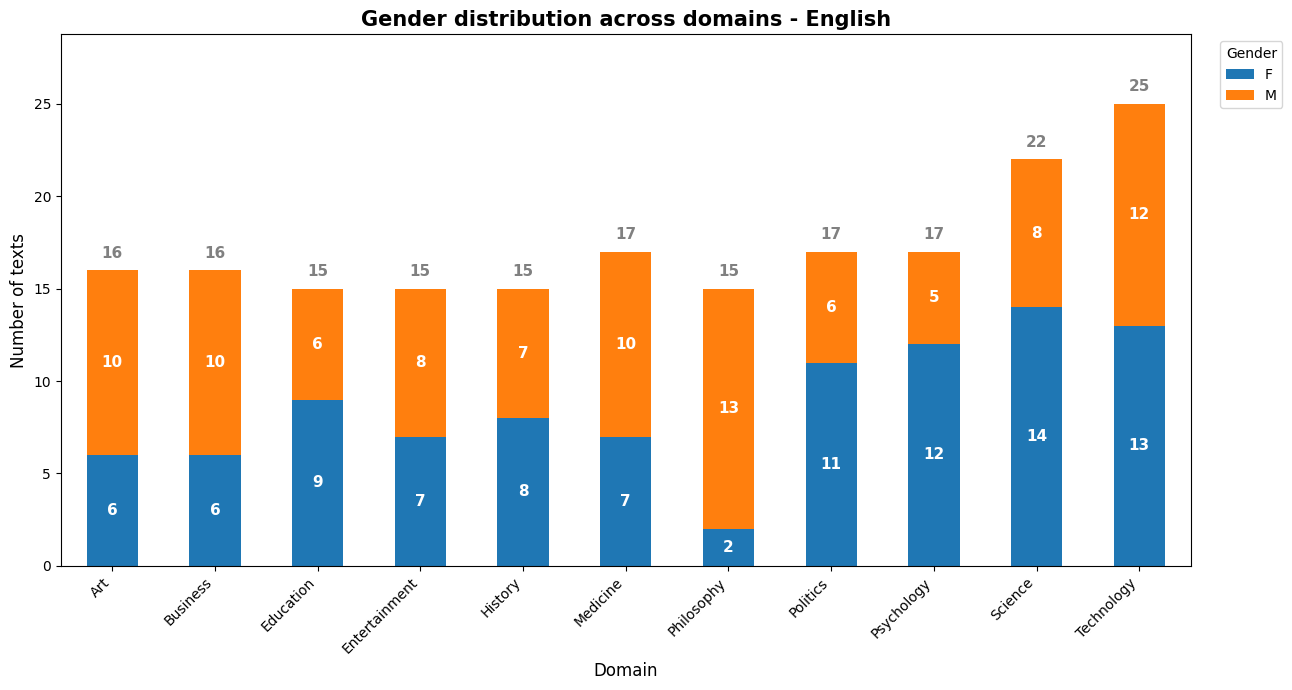

In [25]:
# English
plot_gender_stacked(
    en_texts,
    "Gender distribution across domains - English"
)